# Diagnose PSO runtime
Select `/home/xuesi.ma/.conda/envs/ligoopt/bin/python` as the notebook kernel, then restart the kernel and **Run All**. Tables use NumPy and IPython; pandas is not required. It benchmarks an existing checkpoint; it does not train, launch the 40-round experiment, or write experiment data.

**Current code:** 20 particles × (100 steps + initial swarm) × 5 cavity graphs = **10,100 graph predictions per PSO** in perturbed mode. The surrogate batches each swarm into 20 nominal graphs and 80 perturbed graphs, so graph count is different from neural-network forward-call count (normally 202 forwards). Eleven minutes corresponds to about 65 ms per graph **including all overhead**, not necessarily neural-network time.

One visible candidate is `kat_manipulation`: each graph starts with a KAT deep copy and two 1001 × 1001 aperture maps. The measurements below determine how much that costs relative to beam tracing, graph conversion, and the GNN.

Defaults sample only 3 PSO steps, plus a few swarm benchmarks. Run on an otherwise idle machine for comparable measurements. If another experiment shares the CPU/GPU, the measurements include that contention. Restart the kernel after editing project code.


In [1]:
from pathlib import Path
import ast
import csv
import html
import os
import sys
import time
import json
import hashlib
import platform
import importlib.metadata
import cProfile
import pstats
import io
from contextlib import contextmanager, ExitStack
from functools import wraps
from unittest.mock import patch
from collections import defaultdict
from datetime import datetime, timezone

EXPECTED_PYTHON = Path("/home/xuesi.ma/.conda/envs/ligoopt/bin/python")
if Path(sys.executable).resolve() != EXPECTED_PYTHON.resolve():
    raise RuntimeError(
        f"Select {EXPECTED_PYTHON} as this notebook's Python kernel, then restart and Run All. "
        f"Current interpreter: {sys.executable}"
    )

# Locate the project without importing run.py or starting its experiment.
ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / "run.py").is_file() and (p / "PSOoptimizer.py").is_file()), None)
if ROOT is None:
    raise RuntimeError("Open this notebook from the ligo-opt project directory.")
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Read only the literal run number; other settings below are explicit and editable.
tree = ast.parse((ROOT / "run.py").read_text())
RUN_NUMBER = next(ast.literal_eval(n.value) for n in tree.body
                  if isinstance(n, ast.Assign)
                  and any(isinstance(t, ast.Name) and t.id == "RUN_NUMBER" for t in n.targets))
MODEL_PATH = ROOT / f"GNN/models/run{RUN_NUMBER}/base_30_gat10_kan5.pt"
# Set MODEL_PATH to a fine-tuned round's .pt file to investigate that checkpoint.
POPULATION = 20
FULL_PSO_STEPS = 100
OUTER_ROUNDS = 40
SAMPLE_STEPS = 3
REPEATS = 3
SEED = 9302
LOWER = [-1934 - 2200, 2245 - 500]
UPPER = [-1934 + 500, 2245 + 2000]
PORT = "p_ITM_p2_i"
OBSERVED_PSO_MINUTES = 11.0
EXPORT_RESULTS = False  # Optional: writes only under profiling_results/.

if not MODEL_PATH.is_file():
    candidates = sorted((ROOT / "GNN/models").glob("**/*.pt"))
    print("Available checkpoints:", *candidates, sep="\n")
    raise FileNotFoundError(f"Set MODEL_PATH to an existing checkpoint: {MODEL_PATH}")
assert SAMPLE_STEPS > 0 and REPEATS > 0 and POPULATION > 0
print("Project:", ROOT)
print("Checkpoint:", MODEL_PATH)


Project: /home/xuesi.ma/ligo-opt
Checkpoint: /home/xuesi.ma/ligo-opt/GNN/models/run9/base_30_gat10_kan5.pt


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch_geometric as pyg
from IPython.display import display, HTML
import PSOoptimizer as opt
import GNN.GNN_run as gnn_module
import GNN.GNN_utils as graph_utils
from utils.finesse_base import base_kat, gnn_base_kat
from sko.tools import func_transformer

# Render tables and export CSV using existing dependencies only (no pandas).
def display_table(rows):
    rows = list(rows)
    if not rows:
        print("No rows.")
        return
    columns = list(rows[0])
    def formatted(value):
        return f"{value:.6g}" if isinstance(value, (float, np.floating)) else str(value)
    header = "".join(f"<th>{html.escape(str(key))}</th>" for key in columns)
    body = "".join("<tr>" + "".join(
        f"<td>{html.escape(formatted(row.get(key, '')))}</td>" for key in columns
    ) + "</tr>" for row in rows)
    display(HTML(f"<table><thead><tr>{header}</tr></thead><tbody>{body}</tbody></table>"))

def summarize(rows, group_key, metrics):
    summaries = []
    for group in dict.fromkeys(row[group_key] for row in rows):
        result = {group_key: group}
        selected = [row for row in rows if row[group_key] == group]
        for metric in metrics:
            values = np.array([row[metric] for row in selected], dtype=float)
            for label, fn in [("median", np.median), ("min", np.min), ("max", np.max)]:
                result[f"{metric}_{label}"] = float(fn(values))
        summaries.append(result)
    return summaries

def write_csv(path, rows):
    with path.open("w", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=list(rows[0]))
        writer.writeheader()
        writer.writerows(rows)

def package_version(name):
    try:
        return importlib.metadata.version(name)
    except importlib.metadata.PackageNotFoundError:
        return "unknown"

source_files = ["run.py", "PSOoptimizer.py", "GNN/GNN_run.py",
                "GNN/GNN_utils.py", "GNN/power_predictor.py", "utils/calc.py",
                "utils/finesse_base.py", "perturbation.py"]
metadata = {
    "timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "python": sys.version,
    "executable": sys.executable,
    "platform": platform.platform(),
    "packages": {p: package_version(p) for p in
                 ["torch", "torch-geometric", "finesse", "scikit-opt"]},
    "cuda_available": torch.cuda.is_available(),
    "torch_threads": torch.get_num_threads(),
    "torch_interop_threads": torch.get_num_interop_threads(),
    "checkpoint": str(MODEL_PATH),
    "checkpoint_bytes": MODEL_PATH.stat().st_size,
    "checkpoint_mtime": MODEL_PATH.stat().st_mtime,
    "evaluation_mode": opt.EVALUATION_MODE,
    "cost_mode": opt.COST_MODE,
    "source_sha256": {p: hashlib.sha256((ROOT / p).read_bytes()).hexdigest()
                      for p in source_files},
}
print(json.dumps(metadata, indent=2))
print("Explicit benchmark settings:", dict(population=POPULATION,
      steps=FULL_PSO_STEPS, rounds=OUTER_ROUNDS, lower=LOWER, upper=UPPER))
print("Compare these settings with run.py if you change the experiment configuration.")


/home/xuesi.ma/.conda/envs/ligoopt/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{
  "timestamp_utc": "2026-09-08T21:38:50.088450+00:00",
  "python": "3.13.13 | packaged by conda-forge | (main, Apr  8 2026, 02:00:33) [GCC 14.3.0]",
  "executable": "/home/xuesi.ma/.conda/envs/ligoopt/bin/python",
  "platform": "Linux-4.18.0-553.159.1.el8_10.x86_64-x86_64-with-glibc2.28",
  "packages": {
    "torch": "2.6.0",
    "torch-geometric": "2.6.1",
    "finesse": "3.0.0",
    "scikit-opt": "0.6.6"
  },
  "cuda_available": true,
  "torch_threads": 40,
  "torch_interop_threads": 40,
  "checkpoint": "/home/xuesi.ma/ligo-opt/GNN/models/run9/base_30_gat10_kan5.pt",
  "checkpoint_bytes": 151533604,
  "checkpoint_mtime": 1788901902.1190028,
  "evaluation_mode": "perturbed",
  "cost_mode": "perturbation",
  "source_sha256": {
    "run.py": "13dadb081d81286ce8f37c55bc220d4eb38719745833f2bf8c6ebd8982960947",
    "PSOoptimizer.py": "f963d1dc66fa7cdf2de7e1da502262ac52d3dcefc3a183ec81098abd820cdadf",
    "GNN/GNN_run.py": "bcde3a93a51b67069374cb28c2f21a6874ff2ddd00e658b62cd6da2ab2828e94"

## Load the actual PSO objective once
The timer includes checkpoint loading and wrapper construction. All later benchmarks reuse this objective, as the production PSO does. The first evaluation can have additional initialization overhead; it is reported separately.


In [3]:
def sync():
    if torch.cuda.is_available():
        torch.cuda.synchronize()

def timed(fn):
    sync()
    start = time.perf_counter()
    value = fn()
    sync()
    return value, time.perf_counter() - start

objective, load_seconds = timed(
    lambda: opt.main_wrapper_PSO(gnn_base_kat, PORT, model_path=MODEL_PATH))
# Use the same adapter as scikit-opt, supporting scalar and vectorized objectives.
evaluate_swarm = func_transformer(objective)
vectorized = getattr(objective, "mode", None) == "vectorization"
# Reuse the predictor held by the closure, avoiding a second large model.
closure = dict(zip(objective.__code__.co_freevars,
                   [cell.cell_contents for cell in (objective.__closure__ or ())]))
predictor = closure.get("predictor_GNN")
if predictor is None:
    raise RuntimeError("Cannot locate the objective's predictor; the closure API has changed.")
print(f"Model/wrapper load: {load_seconds:.3f} s")
print("Objective vectorized:", vectorized)
print("Device:", predictor.device, "| Model training flag:", predictor.model.training)
print(f"Model parameters: {sum(p.numel() for p in predictor.model.parameters()):,}")
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name())

graphs_per_particle = 5 if opt.EVALUATION_MODE == "perturbed" else 1
swarm_evaluations = FULL_PSO_STEPS + 1
particle_evaluations = POPULATION * swarm_evaluations
graph_evaluations = particle_evaluations * graphs_per_particle
expected_forwards = swarm_evaluations * (2 if graphs_per_particle == 5 else 1) if vectorized else graph_evaluations
display_table([
    {"quantity": "Swarm evaluations per PSO", "count": swarm_evaluations},
    {"quantity": "Particle objective evaluations per PSO", "count": particle_evaluations},
    {"quantity": "Cavity graphs per PSO", "count": graph_evaluations},
    {"quantity": "Expected GNN forwards per PSO (current implementation)", "count": expected_forwards},
])
print(f"{OBSERVED_PSO_MINUTES:g} min / {graph_evaluations:,} graphs = "
      f"{OBSERVED_PSO_MINUTES * 60 / graph_evaluations * 1000:.1f} ms/graph including overhead")


Model/wrapper load: 0.602 s
Objective vectorized: True
Device: cuda | Model training flag: False
Model parameters: 37,854,813
GPU: Tesla V100-SXM2-16GB


quantity,count
Swarm evaluations per PSO,101
Particle objective evaluations per PSO,2020
Cavity graphs per PSO,10100
Expected GNN forwards per PSO (current implementation),202


11 min / 10,100 graphs = 65.3 ms/graph including overhead


## Uninstrumented objective timings
A single particle still requests five graphs in perturbed mode. A swarm can amortize GPU work across particles. Repeated swarm tests use a fixed, reproducible set spanning the configured bounds; the short PSO later measures moving particles.

Infinity can be a valid objective penalty for an invalid/unstable point. The finite-cost fraction helps interpret the sampled workload.


In [4]:
rng = np.random.default_rng(SEED)
swarm = rng.uniform(LOWER, UPPER, size=(POPULATION, 2))
point = np.array([[-1934.0, 2245.0]])
first_cost, first_seconds = timed(lambda: evaluate_swarm(point))
print(f"First particle evaluation: {first_seconds:.3f} s; cost={np.asarray(first_cost).ravel()}")

baseline_rows = []
for label, positions in [("one particle", point), ("full swarm", swarm)]:
    # Warm the relevant batch size separately.
    evaluate_swarm(positions)
    for repeat in range(REPEATS):
        values, seconds = timed(lambda: evaluate_swarm(positions))
        values = np.asarray(values).reshape(-1)
        baseline_rows.append({
            "workload": label, "repeat": repeat + 1,
            "particles": len(positions), "graphs": len(positions) * graphs_per_particle,
            "seconds": seconds,
            "ms_per_graph": 1000 * seconds / (len(positions) * graphs_per_particle),
            "finite_fraction": float(np.isfinite(values).mean()),
        })
        print(f"{label}, repeat {repeat + 1}: {seconds:.3f} s")
baseline = baseline_rows
display_table(baseline)
display_table(summarize(baseline, "workload", ["seconds", "ms_per_graph"]))


First particle evaluation: 0.271 s; cost=[1.00853657]
one particle, repeat 1: 0.105 s
one particle, repeat 2: 0.102 s
one particle, repeat 3: 0.106 s
full swarm, repeat 1: 1.939 s
full swarm, repeat 2: 1.802 s
full swarm, repeat 3: 1.851 s


workload,repeat,particles,graphs,seconds,ms_per_graph,finite_fraction
one particle,1,1,5,0.104969,20.9937,1
one particle,2,1,5,0.102337,20.4675,1
one particle,3,1,5,0.1057,21.14,1
full swarm,1,20,100,1.93938,19.3938,0.8
full swarm,2,20,100,1.80171,18.0171,0.8
full swarm,3,20,100,1.85079,18.5079,0.8


workload,seconds_median,seconds_min,seconds_max,ms_per_graph_median,ms_per_graph_min,ms_per_graph_max
one particle,0.104969,0.102337,0.1057,20.9937,20.4675,21.14
full swarm,1.85079,1.80171,1.93938,18.5079,18.0171,19.3938


## Attribute one swarm's time to the actual code
Temporary wrappers measure nested calls and restore all methods afterward, including if an exception occurs. **Exclusive time** subtracts instrumented child calls, so these rows partition the measured objective time. **Inclusive time** includes children and must not be summed.

GPU synchronization makes forward timings meaningful but adds overhead; use the uninstrumented results above for runtime estimates. “GNN forward” covers the neural network only. Tensor batching, transfers, output conversion, and other unwrapped work appear in their enclosing method's exclusive time. Finesse *beam tracing* for graph features is distinct from a full Finesse simulation.


stage,calls,inclusive_s,exclusive_s,exclusive_percent
KAT copy / aperture maps / ROC edits,100,1.30417,1.30417,71.4124
KAT to NetworkX,100,0.254049,0.254049,13.911
Beam trace / stability / q,100,0.166403,0.166403,9.11174
NetworkX to PyG,100,0.0528989,0.0528989,2.89659
GNN forward,2,0.0245492,0.0245492,1.34424
Prepare data (other),100,0.485794,0.0124432,0.681351
Batch / transfer / output (other),2,0.51703,0.00668679,0.366149
Objective / PSO adapter (other),1,1.82625,0.00311131,0.170366
Cost calculation,20,0.00194016,0.00194016,0.106237


Instrumented swarm: 1.826 s
Full Finesse simulation calls: 0
Model reloads during objective: 0
Peak PyTorch CUDA allocated: 0.21 GiB
Peak PyTorch CUDA reserved: 0.23 GiB


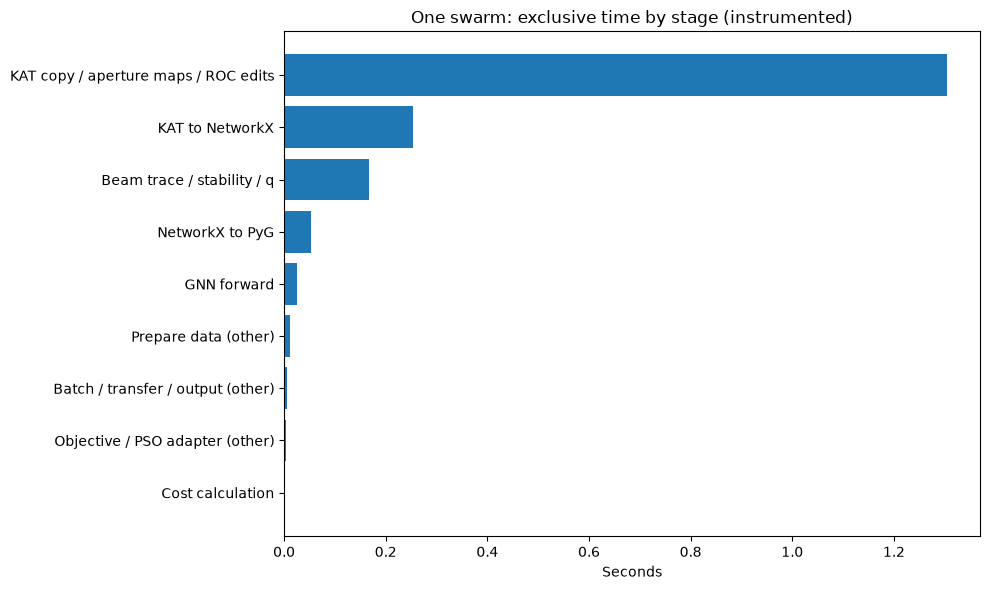

In [5]:
@contextmanager
def stage_profile():
    records = defaultdict(lambda: {"calls": 0, "inclusive_s": 0.0, "exclusive_s": 0.0})
    stack = []

    def wrap(label, fn):
        @wraps(fn)
        def measured(*args, **kwargs):
            sync()
            frame = {"children": 0.0}
            start = time.perf_counter()
            stack.append(frame)
            try:
                return fn(*args, **kwargs)
            finally:
                sync()
                elapsed = time.perf_counter() - start
                stack.pop()
                records[label]["calls"] += 1
                records[label]["inclusive_s"] += elapsed
                records[label]["exclusive_s"] += elapsed - frame["children"]
                if stack:
                    stack[-1]["children"] += elapsed
        return measured

    with ExitStack() as contexts:
        targets = [
            (opt, "kat_manipulation", "KAT copy / aperture maps / ROC edits"),
            (graph_utils, "circular_aperture", "Aperture amplitude arrays"),
            (graph_utils, "Map", "Surface Map construction"),
            (predictor, "_beam_q_values", "Beam trace / stability / q"),
            (gnn_module, "model_to_nx_port", "KAT to NetworkX"),
            (pyg.utils, "from_networkx", "NetworkX to PyG"),
            (predictor, "_prepare_data", "Prepare data (other)"),
            (predictor.model, "forward", "GNN forward"),
            (predictor, "run_batch", "Batch / transfer / output (other)"),
            (opt, "calc_cost", "Cost calculation"),
            (opt, "finesse_sim", "Full Finesse simulation"),
            (predictor, "_load_model", "Unexpected model reload"),
        ]
        for owner, name, label in targets:
            if hasattr(owner, name):
                contexts.enter_context(patch.object(owner, name, wrap(label, getattr(owner, name))))
        yield records, wrap

if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()
with stage_profile() as (stage_records, instrument):
    profiled_costs = instrument("Objective / PSO adapter (other)", evaluate_swarm)(swarm)
stage_table = sorted([
    {"stage": name, **values} for name, values in stage_records.items()
], key=lambda row: row["exclusive_s"], reverse=True)
profile_total = stage_records["Objective / PSO adapter (other)"]["inclusive_s"]
for row in stage_table:
    row["exclusive_percent"] = 100 * row["exclusive_s"] / profile_total
display_table(stage_table)
print(f"Instrumented swarm: {profile_total:.3f} s")
print("Full Finesse simulation calls:", stage_records.get("Full Finesse simulation", {}).get("calls", 0))
print("Model reloads during objective:", stage_records.get("Unexpected model reload", {}).get("calls", 0))
if torch.cuda.is_available():
    print(f"Peak PyTorch CUDA allocated: {torch.cuda.max_memory_allocated() / 2**30:.2f} GiB")
    print(f"Peak PyTorch CUDA reserved: {torch.cuda.max_memory_reserved() / 2**30:.2f} GiB")

stage_figure, ax = plt.subplots(figsize=(10, 6))
ordered_stages = list(reversed(stage_table))
ax.barh([row["stage"] for row in ordered_stages],
        [row["exclusive_s"] for row in ordered_stages])
ax.set_title("One swarm: exclusive time by stage (instrumented)")
ax.set_xlabel("Seconds")
stage_figure.tight_layout()
plt.show()


## Isolate Finesse model deep-copy time
This benchmark times only `gnn_base_kat.deepcopy()`. It excludes ROC assignments, fixed-q command parsing, aperture-map construction, beam tracing, graph conversion, GPU transfer, GNN inference, and cost calculation.

The current GNN objective creates one copied KAT per graph, so the notebook also projects the isolated copy cost across one swarm and one complete PSO. This projection assumes copy cost remains approximately constant across evaluations. The cell reports whether the GNN base template already contains surface maps, because copying a mapped base model would measure a different and much larger object.

In [6]:
import gc

gnn_base_has_aperture_maps = (
    gnn_base_kat.ITM.surface_map is not None or gnn_base_kat.ETM.surface_map is not None
)
print("GNN base template contains aperture maps:", gnn_base_has_aperture_maps)

# Warm up Finesse's copy path once. Garbage collection occurs outside each timer.
warmup_copy = gnn_base_kat.deepcopy()
del warmup_copy

deepcopy_rows = []
deepcopy_repeats = max(REPEATS, 10)
for repeat in range(deepcopy_repeats):
    gc.collect()
    copied_kat, seconds = timed(gnn_base_kat.deepcopy)
    deepcopy_rows.append({
        "repeat": repeat + 1,
        "seconds": seconds,
        "milliseconds": seconds * 1000,
    })
    del copied_kat

deepcopy_seconds = np.array([row["seconds"] for row in deepcopy_rows])
median_deepcopy_seconds = float(np.median(deepcopy_seconds))
copies_per_swarm = POPULATION * graphs_per_particle
copies_per_pso = copies_per_swarm * swarm_evaluations
deepcopy_projection = {
    "median_deepcopy_milliseconds": median_deepcopy_seconds * 1000,
    "copies_per_swarm": copies_per_swarm,
    "projected_copy_seconds_per_swarm": median_deepcopy_seconds * copies_per_swarm,
    "copies_per_pso": copies_per_pso,
    "projected_copy_minutes_per_pso": median_deepcopy_seconds * copies_per_pso / 60,
}

display_table(deepcopy_rows)
display_table([
    {"quantity": key, "value": value}
    for key, value in deepcopy_projection.items()
])

GNN base template contains aperture maps: False


repeat,seconds,milliseconds
1,0.00751932,7.51932
2,0.00903984,9.03984
3,0.00912812,9.12812
4,0.0110126,11.0126
5,0.0115123,11.5123
6,0.00989885,9.89885
7,0.0101052,10.1052
8,0.0285835,28.5835
9,0.0155715,15.5715
10,0.007706,7.706


quantity,value
median_deepcopy_milliseconds,10.002
copies_per_swarm,100
projected_copy_seconds_per_swarm,1.0002
copies_per_pso,10100
projected_copy_minutes_per_pso,1.68367


## Isolate forward-only inference on prepared graphs
This removes KAT construction, graph conversion, and host/device transfers from the timer. It reuses a nominal graph to form the same batch sizes used by the current objective (1, 20, and 80 with default settings). It measures throughput rather than prediction quality or the exact mixed geometries in a swarm. Compare these numbers with end-to-end times, not directly with a full PSO.

Only one prepared batch is retained at a time.


In [7]:
example_kat = opt.kat_manipulation(-1934.0, 2245.0, gnn_base_kat, nominal_q_value=None, include_aperture_maps=False)
example_data, _, _ = predictor._prepare_data(example_kat)
del example_kat
forward_rows = []
batch_sizes = sorted({1, POPULATION, *([4 * POPULATION] if graphs_per_particle == 5 else [])})
for batch_size in batch_sizes:
    batch = pyg.data.Batch.from_data_list([example_data] * batch_size).to(predictor.device)
    with torch.no_grad():
        predictor.model(batch)
        for repeat in range(REPEATS):
            output, seconds = timed(lambda: predictor.model(batch))
            forward_rows.append({"graphs": batch_size, "repeat": repeat + 1,
                                 "seconds": seconds, "ms_per_graph": seconds * 1000 / batch_size})
            del output
    del batch
forward_table = forward_rows
display_table(summarize(forward_table, "graphs", ["seconds", "ms_per_graph"]))


graphs,seconds_median,seconds_min,seconds_max,ms_per_graph_median,ms_per_graph_min,ms_per_graph_max
1,0.0115877,0.0113844,0.0117289,11.5877,11.3844,11.7289
20,0.0125543,0.0120984,0.0125762,0.627714,0.604918,0.628808
80,0.0123363,0.0122774,0.0141327,0.154204,0.153468,0.176659


## Short production-style PSO and runtime projection
Uses the actual `SteppablePSO`, weights and bounds from the current run configuration, including evaluation during construction and initialization of personal/global bests. No real-Finesse feedback or fine-tuning is performed.

The projection assumes the mean of the sampled moving-swarm steps represents all 100 steps. Increase SAMPLE_STEPS if time changes as particles move between stable and unstable regions. The observed min/max projection is a sample range, not a confidence interval.


PSO step 1/3: 1.900 s
PSO step 2/3: 1.903 s
PSO step 3/3: 1.618 s


step,seconds,best_cost,finite_fraction
1,1.90029,0.000168164,0.65
2,1.90345,0.000159814,0.65
3,1.61755,0.000150498,0.9


PSO construction (includes initial swarm): 1.835 s
Observed particle evaluations: 80; expected: 80
Objective Python calls: 4 (batched calls count whole swarms)


quantity,value
load_seconds,0.60157
first_particle_seconds,0.2707
pso_init_seconds,1.83529
sampled_step_mean_seconds,1.80709
estimated_pso_minutes_including_load,3.05244
estimated_all_rounds_pso_hours,2.03496
step_sample_min_projection_minutes,2.73653
step_sample_max_projection_minutes,3.21303
observed_pso_minutes,11


The round total additionally includes real-Finesse feedback and fine-tuning.
Base data generation and base training are additional one-time experiment costs.


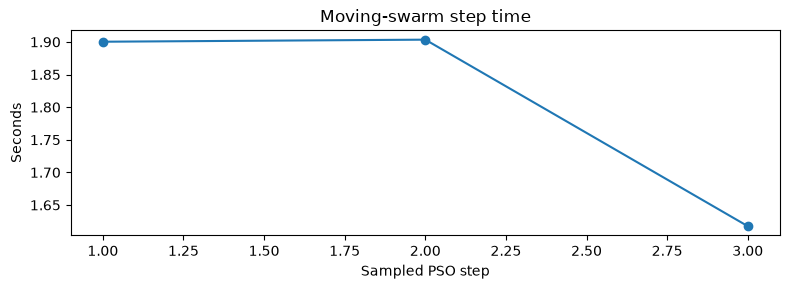

In [8]:
objective_calls = []
@wraps(objective)
def counted_objective(params):
    values, seconds = timed(lambda: objective(params))
    arr = np.asarray(params)
    objective_calls.append({"particles": len(arr) if arr.ndim == 2 else 1,
                            "seconds": seconds})
    return values
if vectorized:
    counted_objective.mode = "vectorization"

random_state = np.random.get_state()
step_rows = []
try:
    np.random.seed(SEED)
    pso, init_seconds = timed(lambda: opt.SteppablePSO(
        func=counted_objective, n_dim=2, pop=POPULATION, max_iter=FULL_PSO_STEPS,
        lb=LOWER, ub=UPPER, w=0.9, c1=2.0, c2=0.4, verbose=False))
    pso.update_pbest()
    pso.update_gbest()
    for step in range(SAMPLE_STEPS):
        _, seconds = timed(pso.step)
        step_rows.append({"step": step + 1, "seconds": seconds,
                          "best_cost": float(np.asarray(pso.gbest_y).item()),
                          "finite_fraction": float(np.isfinite(pso.Y).mean())})
        print(f"PSO step {step + 1}/{SAMPLE_STEPS}: {seconds:.3f} s")
finally:
    np.random.set_state(random_state)

steps = step_rows
step_seconds = np.array([row["seconds"] for row in steps])
display_table(steps)
actual_particles = sum(row["particles"] for row in objective_calls)
expected_particles = POPULATION * (SAMPLE_STEPS + 1)
print(f"PSO construction (includes initial swarm): {init_seconds:.3f} s")
print(f"Observed particle evaluations: {actual_particles}; expected: {expected_particles}")
print(f"Objective Python calls: {len(objective_calls)} (batched calls count whole swarms)")
if actual_particles != expected_particles:
    print("Call count differs from the assumption; inspect before trusting the projection.")

mean_step_seconds = float(step_seconds.mean())
estimated_pso_seconds = load_seconds + init_seconds + FULL_PSO_STEPS * mean_step_seconds
projection = {
    "load_seconds": load_seconds,
    "first_particle_seconds": first_seconds,
    "pso_init_seconds": init_seconds,
    "sampled_step_mean_seconds": mean_step_seconds,
    "estimated_pso_minutes_including_load": estimated_pso_seconds / 60,
    "estimated_all_rounds_pso_hours": estimated_pso_seconds * OUTER_ROUNDS / 3600,
    "step_sample_min_projection_minutes": (load_seconds + init_seconds + FULL_PSO_STEPS * float(step_seconds.min())) / 60,
    "step_sample_max_projection_minutes": (load_seconds + init_seconds + FULL_PSO_STEPS * float(step_seconds.max())) / 60,
    "observed_pso_minutes": OBSERVED_PSO_MINUTES,
}
display_table([{"quantity": key, "value": value} for key, value in projection.items()])
print("The round total additionally includes real-Finesse feedback and fine-tuning.")
print("Base data generation and base training are additional one-time experiment costs.")
plt.figure(figsize=(8, 3))
plt.plot([row["step"] for row in steps], step_seconds, marker="o")
plt.xlabel("Sampled PSO step")
plt.ylabel("Seconds")
plt.title("Moving-swarm step time")
plt.tight_layout()
plt.show()


## Python call profile
Profiles one additional fixed swarm after timing wrappers have been removed. Sort by cumulative time to find expensive call paths, then by self time to locate work inside those paths. Profiling adds overhead and CPU statistics do not accurately separate asynchronous CUDA execution; use the synchronized stage and forward timings for GPU attribution.


In [9]:
profiler = cProfile.Profile()
def profile_one_swarm():
    result = evaluate_swarm(swarm)
    sync()
    return result

# Keep profiling inside one function call, so IPython's cell/event-loop work
# does not appear as objective time or inflate call counts.
sync()
profiler.runcall(profile_one_swarm)
profile_text = io.StringIO()
pstats.Stats(profiler, stream=profile_text).strip_dirs().sort_stats("cumulative").print_stats(35)
pstats.Stats(profiler, stream=profile_text).strip_dirs().sort_stats("tottime").print_stats(25)
print(profile_text.getvalue())


         12417718 function calls (10968253 primitive calls) in 5.771 seconds

   Ordered by: cumulative time
   List reduced from 925 to 35 due to restriction <35>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      2/1    0.000    0.000    5.770    5.770 3678012051.py:2(profile_one_swarm)
      2/1    0.001    0.000    5.770    5.770 PSOoptimizer.py:196(batched_cost_fn)
      100    0.001    0.000    4.233    0.042 GNN_utils.py:125(kat_manipulation)
      100    0.009    0.000    3.542    0.035 model.py:455(deepcopy)
1161468/292    1.332    0.000    3.507    0.012 copy.py:119(deepcopy)
      100    0.052    0.001    3.503    0.035 model.py:458(__deepcopy__)
100100/200    0.671    0.000    3.320    0.017 copy.py:218(_deepcopy_dict)
42400/3400    0.152    0.000    3.202    0.001 copy.py:248(_reconstruct)
        2    0.001    0.000    1.626    0.813 GNN_run.py:71(run_batch)
      100    0.003    0.000    1.593    0.016 GNN_run.py:51(_prepare_data)
 1300/900   

## Read the results
- **Standalone deep-copy projection:** this is the cost of `gnn_base_kat.deepcopy()` alone. Compare its projected swarm time with the end-to-end swarm measurement; the difference is all other objective work.
- **KAT construction or maps dominate:** inspect repeated deep copies and rebuilding both million-point aperture maps for every graph. Consider reuse or a dedicated graph-feature path only after checking that powers, q values, and objective values remain equivalent.
- **Beam tracing or conversion dominates:** batching neural-network forwards alone cannot remove this CPU work. Investigate reusing graph topology and constructing only changing features.
- **GNN forward dominates:** compare the 1-, 20-, and 80-graph forward throughput and check the reported device. The loaded network has hidden size 1000 and 10 message-passing layers, so it is not necessarily cheap.
- **Batch/transfer/output dominates:** inspect PyG batching, tensor movement, and converting outputs back to Python.
- **Short PSO matches ~11 minutes:** the evaluation count and per-swarm work explain the runtime. Forty rounds multiply this cost.
- **Short PSO is much faster:** check source hashes, checkpoint, device, machine load, and whether the original 11-minute measurement included Finesse or fine-tuning.

The current objective requires perturbations (`COST_MODE="perturbation"`). Switching to nominal evaluation would change the optimization objective; this notebook keeps the configured mode.

Measurements here apply to the code and checkpoint loaded by this kernel. They cannot establish what an older process loaded before the source was edited.


In [10]:
if EXPORT_RESULTS:
    stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S_%fZ")
    output_dir = ROOT / "profiling_results" / stamp
    output_dir.mkdir(parents=True, exist_ok=False)
    metadata["benchmark_config"] = {
        "population": POPULATION, "full_pso_steps": FULL_PSO_STEPS,
        "outer_rounds": OUTER_ROUNDS, "sample_steps": SAMPLE_STEPS,
        "repeats": REPEATS, "seed": SEED, "lower": LOWER, "upper": UPPER,
        "port": PORT,
    }
    metadata["projection"] = projection
    metadata["deepcopy_projection"] = deepcopy_projection
    (output_dir / "metadata.json").write_text(json.dumps(metadata, indent=2))
    write_csv(output_dir / "objective_timings.csv", baseline)
    write_csv(output_dir / "deepcopy_timings.csv", deepcopy_rows)
    write_csv(output_dir / "stage_timings.csv", stage_table)
    write_csv(output_dir / "forward_timings.csv", forward_table)
    write_csv(output_dir / "pso_steps.csv", steps)
    (output_dir / "cprofile.txt").write_text(profile_text.getvalue())
    profiler.dump_stats(str(output_dir / "swarm.prof"))
    stage_figure.savefig(output_dir / "stage_timings.png", dpi=160, bbox_inches="tight")
    print("Saved:", output_dir)
else:
    print("Results remain in this notebook. Set EXPORT_RESULTS=True and rerun this cell to export.")


Results remain in this notebook. Set EXPORT_RESULTS=True and rerun this cell to export.
